# Component Separation Notebook

We build the method in three stages: one signal with white noise, the same problem with an auxiliary map, and the full Planck Q/U/I857 application.


## 1. The component separation problem in general

We observe a map

$$d=s+n_0,$$

where $s$ is the unknown signal and $n_0$ is an unknown contamination realization. We assume that we have independent examples $n_i$ drawn from the same distribution as $n_0$.

As a first example, let's set the following goal: find a map $\tilde s$ such that $\tilde{s}+n_i$ is statistically consistent with $d$;

In this framework, `statistically consistent' means that if $\phi(d)$ signifies some vector of summary statistics of $d$, then we require that 

$$\phi(d) \simeq \langle \phi(\tilde{s} + n_i) \rangle_i $$

where the average is taken over the nuisance ensemble $n^{(i)}$. 

But we can also require of the candidate map $\tilde{s}$ that the the residual $d-\tilde{s}$ is statistically consistent with the contamination. Then, this constraint can be written as 


$$\phi(d - \tilde s) \simeq \langle \phi(n_i) \rangle_i $$

Naturally, we could think of additional statistical constraints to be added, but for the moment let's stick to these two.

**Note:** In general, the forward model does not have to be linear or additive: it can take a general form $d = f_z(s)$ where $f$ is a known function and $z$ is some stochastic parameter. For simplicity, here we will only consider the specific case of $d=s+n_0$




### Import the required libraries

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

### Load STL and select the computation device

In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "STL_main").exists():
    ROOT = next(parent for parent in ROOT.parents if (parent / "STL_main").exists())
sys.path.insert(0, str(ROOT))

import STL_main.torch_backend as bk
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch as DataClass

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
bk._DEFAULT_DEVICE = device
bk._DEFAULT_DTYPE = dtype
bk._DEFAULT_COMPLEX_DTYPE = torch.complex64

/Users/tsouros/Desktop/debugging/STL-Dev/STL_main/__init__.py:9: UserWarning: In development mode: Please run 'pip install -e .' in the root directory of the STL repository to properly install the package, its dependencies and enable proper version tracking.
  warnings.warn(


### Load, anti-alias, and downgrade the signal

For this controlled example, we load the turbulece map at its native resolution. The true signal is used to construct and assess the experiment; it is never supplied to the optimizer.

As we would like to run these examples locally on CPU, it would be better to downsample to a resolution of $128\times128$, so that it is more manageable. 

Before downgrading the map, we apply an ideal low-pass beam in Fourier space. Without this beam, Fourier modes above the new Nyquist frequency would fold onto lower frequencies and produce what is called as aliasing.

Applying the beam is equivalent here to retaining only the centered $128\times128$ Fourier modes. We then transform the cropped spectrum back to real space. The factor $128/N$ corrects the orthonormal-FFT normalization, so the amplitude of a constant map is preserved when the number of pixels changes.

In [3]:
s_full = np.load(ROOT / "data/test/Turb_6.npy")[0].astype(np.float64)

def beam_and_downgrade_128(image):
    original_size = image.shape[0]
    spectrum = np.fft.fftshift(np.fft.fft2(image, norm="ortho"))

    # Ideal low-pass beam: retain only modes supported by a 128x128 grid.
    start = (original_size - 128) // 2
    spectrum = spectrum[start:start + 128, start:start + 128]

    downgraded = np.fft.ifft2(
        np.fft.ifftshift(spectrum), norm="ortho"
    ).real
    return downgraded * 128 / original_size

s = beam_and_downgrade_128(s_full)
assert s.shape == (128, 128)

### Create the observation and nuisance examples

The particular noise $n_0$ contaminates the observation. The 100 independent maps in `noise_samples` represent the same noise distribution. 

In this case we assume that the noise is white we which can easily write down analytically. However, here we will only rely on samples of the noise, and not an analytic modelisation of it. 

In [4]:
rng = np.random.default_rng(2)
noise_std = s.std()
n0 = rng.normal(0, noise_std, s.shape)
noise_samples = rng.normal(0, noise_std, (100, *s.shape))
d = s + n0

The first desired constraint is that $\tilde s+n^{(i)}$ should resemble the observed data $d$. The second is that the residual $d-\tilde s$ should resemble nuisance. 

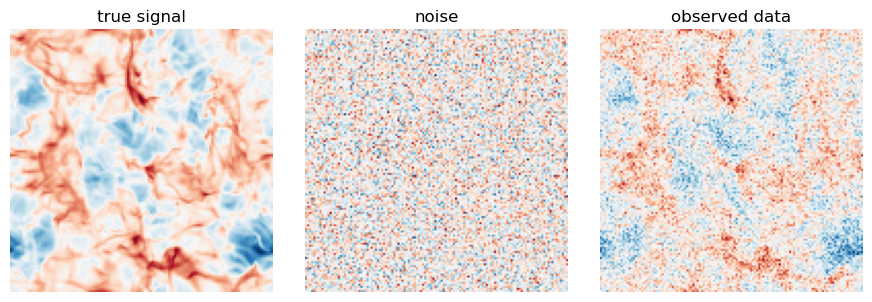

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, image, title in zip(axes, [s, n0, d], ["true signal", "noise", "observed data"]):
    ax.imshow(image, origin="lower", cmap="RdBu_r")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

## 2. Strategy 

Our strategy will be the following: for each constraints that we want to impose, we will introduce an L2 loss such that when optimised with respect to the map, we wil hopefully end up with the desired $\tilde s$. So, for the first constraint, for instance

$$\phi(d) \simeq \big\langle \phi\big(\tilde{s} + n_i\big) \big\rangle_i \leftrightarrow \mathcal{L}(u) = \frac{1}{M} \sum_{i=1}^M|\phi(u + n_{i}) - \phi(d)|^2. $$
Here $M$ is the number of coefficients of $\phi( \cdot)$, and $u$ is the running map.

After convergence, we get the map

$$\tilde s = \argmin_u \mathcal{L}(u)$$

### Move the observed map and nuisance bank to PyTorch

In [6]:
d_t = torch.from_numpy(d).to(device=device, dtype=dtype)
noise_t = torch.from_numpy(noise_samples).to(device=device, dtype=dtype)

## 3. Scattering Transform Statistics

While in principle the summary statistics can be any set of summary statistics one wishes to use, here we will use scattering covariances. These are summary statistics that quantify correlations between orientated scales of an image with itself. If $\lambda = (j, \theta)$ defines a specific choice of orientated scales, and $x$ is an image, then our choice is 

$$S_1^{\lambda_1} \equiv \langle |x \star \Psi^{\lambda_1}| \rangle$$
$$S_2^{\lambda_1} \equiv \langle |x \star \Psi^{\lambda_1}|^2 \rangle$$
$$S_3^{\lambda_1, \lambda_2} \equiv \text{Cov} [x \star \Psi^{\lambda_1}, |x \star \Psi^{\lambda_2}| \star \Psi^{\lambda_1}]$$
$$S_4{\lambda_1, \lambda_2, \lambda_3} \equiv \text{Cov} [ | x \star \Psi^{\lambda_3}| \star \Psi^{\lambda_1}, |x \star \Psi^{\lambda_2}| \star  \Psi^{\lambda_1}]$$
$$\phi(x) \equiv \{\mu / \sigma, S_1, S_2, S_3, S_4 \}$$

where $\mu, \sigma$ signify the mean and the standard deviation of the map $x$, respectiely. 

Notice also that this can be expressed as a cross-summary statistic between two different maps $x_1, x_2$:

$$S_1^{\lambda_1}(x_1) \equiv \langle |x_1 \star \Psi^{\lambda_1}| \rangle$$
$$S_1^{\lambda_1}(x_2) \equiv \langle | x_2 \star \Psi^{\lambda_1}| \rangle$$
$$S_2^{\lambda_1}(x_1, x_2) \equiv \langle (x_1 \star \Psi^{\lambda_1})  (x_2 \star \Psi^{\lambda_1})^* \rangle$$
$$S_3^{\lambda_1, \lambda_2}(x_1, x_2) \equiv \text{Cov} [x_1 \star \Psi^{\lambda_1}, |x_2 \star \Psi^{\lambda_2}| \star \Psi^{\lambda_1}]$$
$$S_4^{\lambda_1, \lambda_2, \lambda_3}(x_1, x_2)  \equiv \text{Cov} [ | x_1 \star \Psi^{\lambda_3}| \star \Psi^{\lambda_1}, |x_2 \star \Psi^{\lambda_2}| \star  \Psi^{\lambda_1}]$$

from which we can define a cross-statistics vector $\phi(x_1, x_2)$, as above. So, this quantifies correlations between an different orientated scales of two different images. 

We are also free to append additional statistics, such as power spectra, for instance. 

## 4. Implementation

In implementating the component separation algorithm, we place the observed map and the nuisance example next to each other as two channels (henceforth I will speak of `channels' for the different objects like $d$ or $n$ which are treated within a unified tensor $X$. It has nothing  to do with frequency channels for instance):

$$
X_{\rm target}^{(i)}=
\begin{bmatrix}
d\\
n^{(i)}
\end{bmatrix}.
$$

This is the object we want to reproduce statistically: one channel corresponds to the observed data, while the other corresponds to the contamination.

Now let $u$ be an estimate of the signal. From $u$ we construct the respective `channels'

$$
X_{\rm run}^{(i)}(u)=
\begin{bmatrix}
u+n^{(i)}\\
d-u
\end{bmatrix}.
$$

Using only one $n^{(i)}$ would make the result depend too strongly on that particular realization, hence overfitting the noise. We therefore select several nuisance realizations at each optimization step. This group is called a **batch**. If it contains $N_b$ realizations, we stack the corresponding objects:

$$
X_{\rm target}=
\left[X_{\rm target}^{(i_1)},\ldots,X_{\rm target}^{(i_{N_b})}\right],
\qquad
X_{\rm run}(u)=
\left[X_{\rm run}^{(i_1)}(u),\ldots,X_{\rm run}^{(i_{N_b})}(u)\right].
$$

Each individual object contains $N_C$ maps of size $H\times W$. After stacking $N_b$ nuisance realizations, both tensors have shape

$$
X\in\mathbb R^{N_b\times N_C\times H\times W}.
$$

In this first example, $N_C=2$. The first axis labels nuisance realizations, the second labels the maps placed in each construction, and the final two axes are image pixels.

STL computes a feature vector $\Phi(X)$ for each construction and averages the statistics over the $N_b$ nuisance realizations. We optimize $u$ by matching the running statistics to the target statistics:

$$
\mathcal L(u)=
\left\|
\Phi\!\left(X_{\rm run}(u)\right)
-
\Phi\!\left(X_{\rm target}\right)
\right\|_2^2.
$$

The following cells implement these constructions one step at a time.

In [7]:
def target_batch(indices):
    data_batch = d_t.expand(len(indices), -1, -1)
    return torch.stack([data_batch, noise_t[indices]], dim=1)

In [8]:
def running_batch(u, indices):
    signal_like = u + noise_t[indices]
    residual = (d_t - u).expand(len(indices), -1, -1)
    return torch.stack([signal_like, residual], dim=1)

### Why the functions return batches

Matching one $n^{(i)}$ could fit its accidental structure. At one update we therefore select $N_b$ nuisance maps and stack their objects:

$$X\in\mathbb R^{N_b\times2\times128\times128}.$$

STL averages the resulting statistics over the first axis.

### Select channel relationships

The Boolean cross-matrix tells STL which channel pairs enter the feature vector. A diagonal $1$ keeps a channel's auto-statistics; an off-diagonal $1$ keeps cross-statistics between two channels.

$$C_2=\begin{pmatrix}1&0\\0&1\end{pmatrix}$$

So, schematically, we can think of of $\Phi$ with this cross matrix as producing the concantenated object: 

$$\Phi(X_{\rm target}^{(i)}) = \begin{bmatrix}
\phi(d)\\
\phi(n_i)
\end{bmatrix}.$$

**Question**: If $C_{01}=1$, what would the constraint be? Why did we not include it?


In [30]:
cross_matrix = torch.tensor([[1,0],[0,1]], dtype=torch.bool, device=device)

### Choose a normalization reference

Scattering coefficients at different scales can differ greatly in magnitude. To see this, consider the power spectrum: small scales have a much weaker magnitude than the large scales, and so the large scales would dominate the loss. For that reason, we should normalise the coefficients, so that all orientated scales contribute more or less equally to the loss.

Here, we choose one fixed reference

$$X_{\rm ref}=[d,n_{\rm ref}]$$

from which STL will derive normalization factors.

In [10]:
reference = torch.stack([d_t, noise_t[0]])
reference_dc = DataClass(reference, pbc=True)

### Define the STL operator, $\Phi$

We use scattering statistics and Gaussian-ring power-spectrum statistics. Twelve smooth radial rings summarize Fourier power.

In [11]:
st_op = reference_dc.get_ST_op(
    WType="Bump-Steerable",
    compute_PS=True,
    power_spectrum_method="gaussian_rings",
    n_bins=12,
    Jmin=0,
)

## Applying the Scattering Operator

once the `st_op` has been defined, we can apply it to an object with `st_op.apply`

### Interlude: Normalisation - What `store_ref` and `load_ref` mean

Let $R=\mathcal N(X_{\rm ref})$ denote the normalization factors derived from the reference. Schematically, these factors are built from reference second-order amplitudes and rescale the raw coefficients so that very large coefficients do not dominate the loss.

`store_ref` performs

$$R\leftarrow\mathcal N(X_{\rm ref})$$

once and caches $R$ inside `st_op`. It does not save a file and does not define the optimization target.

For every later field $X$, `load_ref` computes

$$\Phi_R(X)=\operatorname{Normalize}(\Phi(X);R),$$

using that same cached $R$. Target and running statistics are therefore measured in one fixed system of units. Recomputing $R$ from every batch would give the two sides different normalizations and change the objective itself.

In [12]:
with torch.no_grad():
    st_op.apply(reference_dc, norm="store_ref", compute_cross_matrix=cross_matrix)

### Apply STL while loading the fixed normalization

For each selected nuisance realization, STL returns one vector of $M$ retained coefficients. Before the function returns, we average those vectors over the minibatch:

$$
\overline{\Phi}_R(X)
=
\frac{1}{N_b}\sum_{i=1}^{N_b}\Phi_R\!\left(X^{(i)}\right)
$$

which has a length $M$. This first average is performed by

```python
to_flatten(mean_along_batch=True, keepnans=False)
```

inside `features()`. Thus `features(target_batch(...))` and `features(running_batch(...))` each return one batch-averaged vector of length $M$.

In [13]:
#this is a helper function that helps us apply the operator 

def features(batch, operator=st_op, matrix=cross_matrix, pbc=True):
    field = DataClass(batch, pbc=pbc)
    result = operator.apply(field, norm="load_ref", compute_cross_matrix=matrix)
    return result.to_flatten(mean_along_batch=True, keepnans=False)

### Optimize the candidate signal

We now introduce the optimization. The trainable map starts from $u=d$, which immediately supplies the large-scale structure. At each update, we select $N_b$ nuisance realizations and compute


$$
\mathcal L(u)
=
\frac{1}{M}\sum_{m=1}^{M}|\overline{\Phi}_R\!\left(X_{\rm run}(u)\right) - \overline{\Phi}_R\!\left(X_{\rm target}\right)|^2.
$$

The bar signifies us that `features()`  has already taken the mean of `st_op`, or $\Phi$, over the nuisance minibatch since we set `mean_along_batch=True`. Inside the closure, we then average the squared differences over those coefficients:


In code, this second average is

```python
difference.abs().square().mean()
```

Therefore the two reductions occur at different places:

1. `features(..., mean_along_batch=True)` averages over the $N_b$ nuisance realizations;
2. `.mean()` in the closure averages over the $M$ retained STL coefficients.

The form of the loss does not need to change when constraints are added: we change the fields $X$ and the cross-matrix $C$, while retaining the same batch average and coefficient average.

We proceed as follows: 

1. We choose a minibatch out of the full contamination ensemble $\{ n_i \}$

2. We compute the target $\Phi_R(X_{\rm target})$

3. We take the difference $\mathcal{L}(u) = | \Phi_R(X_{\rm target}) - \Phi_R(X_{\rm run}) (u) | ^2$ 

4. Perform a gradient descent to find 
$$\tilde{s} = \argmin_{u} \mathcal{L}(u)$$

In [14]:
# parameters used only in this optimization stage.
N_ITER = 500 #number of iterations
BATCH_SIZE = 15 #the size of the minibatch for calculating the loss at each iteration
LEARNING_RATE = 1.0
SAMPLE_WITH_REPLACEMENT = False

u = d_t.clone().requires_grad_(True)
optimizer = torch.optim.LBFGS(
    [u], lr=LEARNING_RATE, max_iter=1, line_search_fn=None
)
losses = []

for iteration in range(N_ITER):
    indices = rng.choice(
        len(noise_t), size=BATCH_SIZE, replace=SAMPLE_WITH_REPLACEMENT
    )

    with torch.no_grad():
        target = features(
            target_batch(indices), operator=st_op, matrix=cross_matrix
        )

    def closure():
        optimizer.zero_grad()
        difference = features(running_batch(u, indices)) - target
        loss = difference.abs().square().mean()  # mean over retained coefficients
        loss.backward()
        return loss

    loss = optimizer.step(closure)
    losses.append(loss.item())


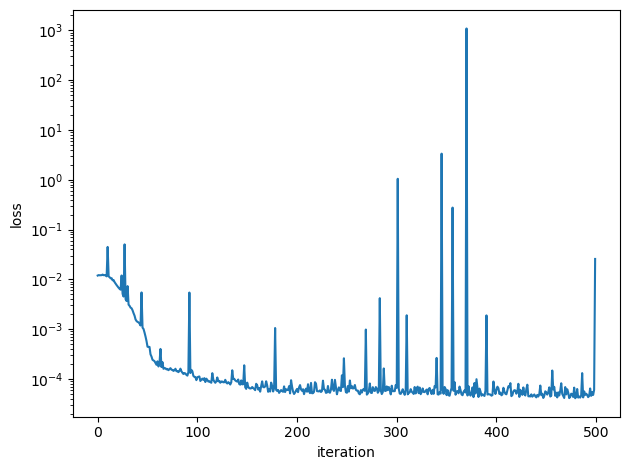

In [15]:
plt.plot(losses)
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.tight_layout()

### Remove modes outside the circular Nyquist disk after optimization

In [16]:
def nyquist_cut(image):
    h, w = image.shape
    ky = h * torch.fft.fftfreq(h, device=image.device)
    kx = w * torch.fft.fftfreq(w, device=image.device)
    ky, kx = torch.meshgrid(ky, kx, indexing="ij")
    mask = kx.square() + ky.square() <= (min(h, w) / 2) ** 2
    return torch.fft.ifft2(torch.fft.fft2(image, norm="ortho") * mask, norm="ortho").real

with torch.no_grad():
    u.copy_(nyquist_cut(u))

### Let's plot our results. First let's compare the true signal $s$ with the recovered $\tilde{s}$, and $d$ with $\tilde s + n_i$ for some randomly chosen $n_i$

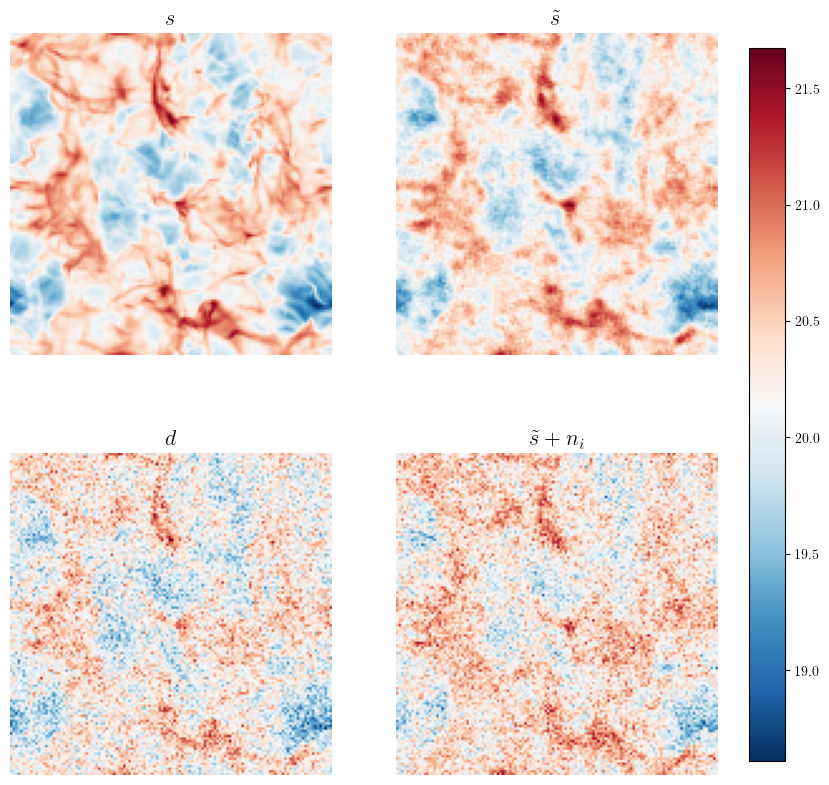

In [29]:
import matplotlib as mpl

mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"

recovered = u.detach().cpu().numpy()
residual = d - recovered
ppc = recovered + noise_samples[1]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for ax, image, title in zip(
    axes,
    [s, recovered, d, ppc],
    [
        r"$s$",
        r"$\tilde{s}$",
        r"$d$",
        r"$\tilde{s} + n_i$",
    ],
):
    im = ax.imshow(image, origin="lower", cmap="RdBu_r")
    ax.set_title(title, fontsize=16)
    ax.axis("off")

fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)

plt.show()

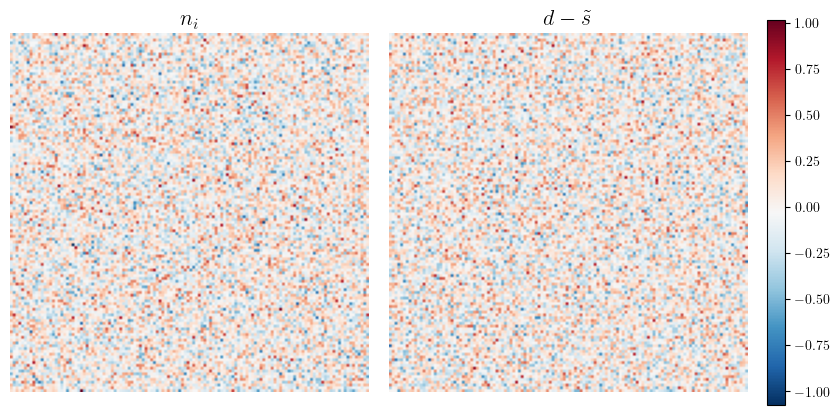

In [18]:
fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.08)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

vmin = min(noise_samples[0].min(), residual.min())
vmax = max(noise_samples[0].max(), residual.max())

for ax, image, title in zip(
    [ax1, ax2],
    [noise_samples[0], residual],
    [
        r"$n_i$",
        r"$d - \tilde{s}$",
    ],
):
    im = ax.imshow(
        image,
        origin="lower",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title, fontsize=16)
    ax.axis("off")

fig.colorbar(im, cax=cax)

plt.show()

### We can also compare histograms

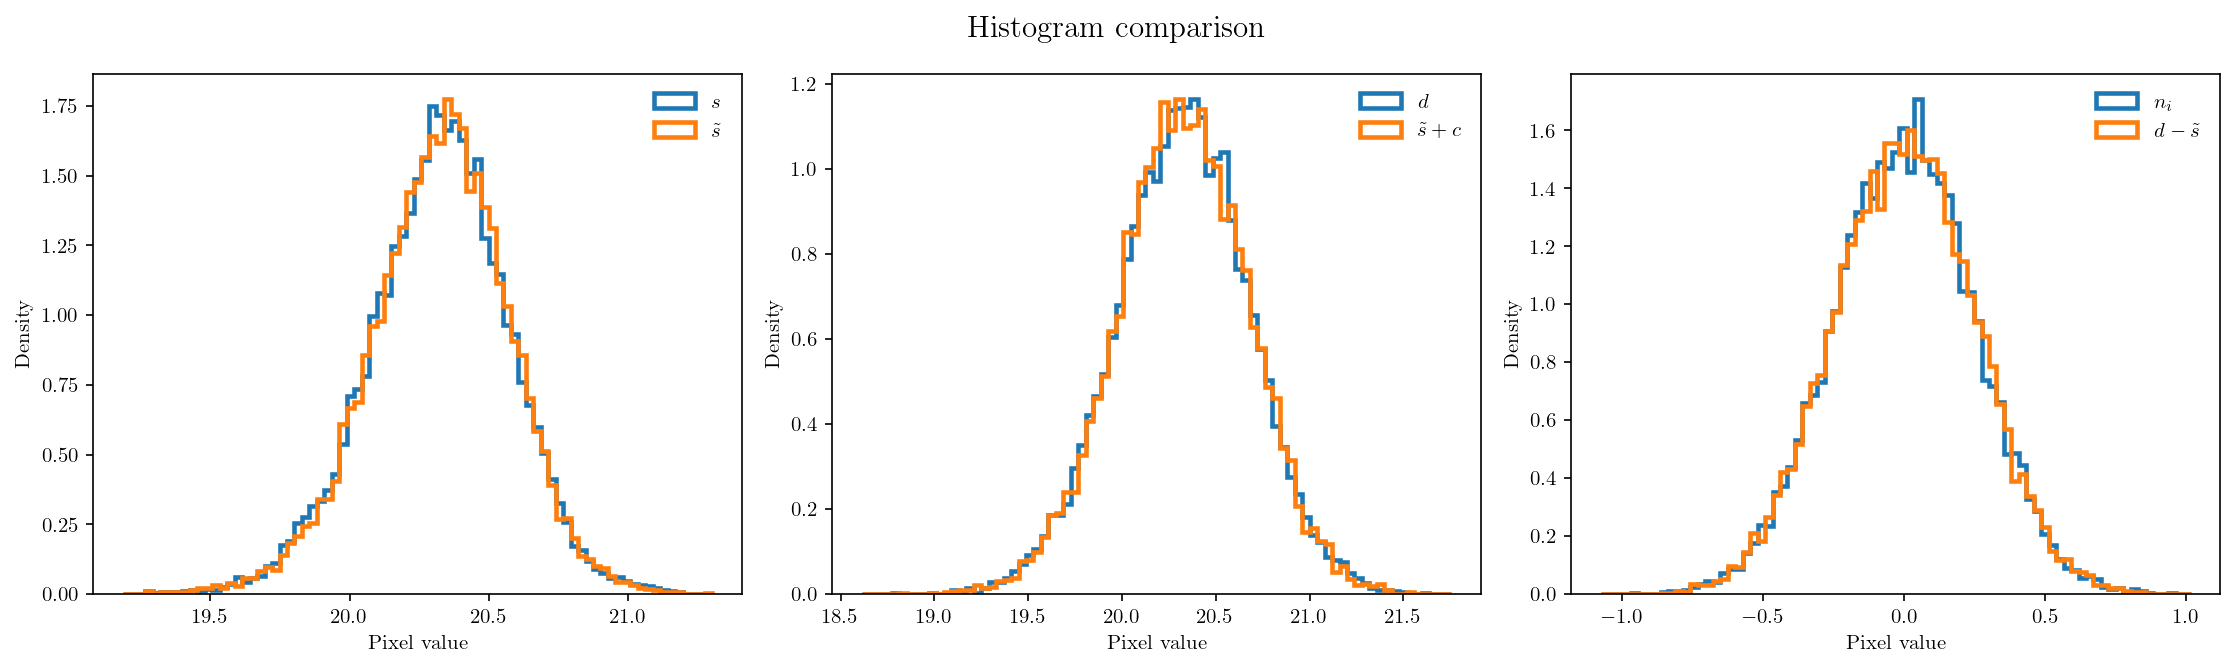

In [19]:
pairs = [
    (s, recovered,        r"$s$",              r"$\tilde{s}$"),
    (d, ppc,              r"$d$",              r"$\tilde{s} + c$"),
    (noise_samples[0],    residual,           r"$n_i$",          r"$d - \tilde{s}$"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)

for ax, (a, b, label_a, label_b) in zip(axes, pairs):
    # Common range for fair comparison
    lo = min(a.min(), b.min())
    hi = max(a.max(), b.max())
    bins = np.linspace(lo, hi, 80)

    ax.hist(
        a.ravel(),
        bins=bins,
        density=True,
        histtype="step",
        lw=2.2,
        label=label_a,
    )
    ax.hist(
        b.ravel(),
        bins=bins,
        density=True,
        histtype="step",
        lw=2.2,
        label=label_b,
    )

    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Density")
    ax.legend(frameon=False)
    # ax.grid(alpha=0.3)

fig.suptitle("Histogram comparison", fontsize=15)
plt.tight_layout()
plt.show()

### Let's plot the power spectra of the maps involved

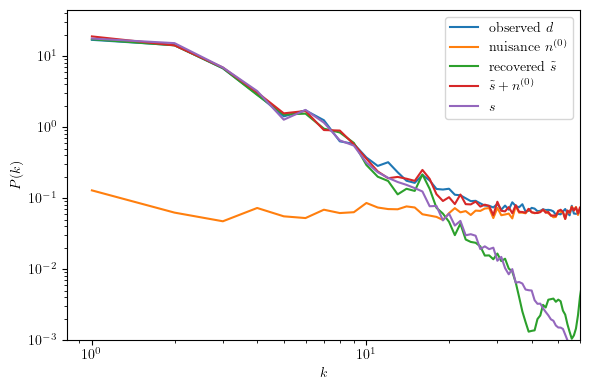

In [31]:
def isotropic_power_spectrum(image):
    # Average 2D Fourier power in integer radial bins.
    power_2d = np.abs(np.fft.fft2(image, norm="ortho")) ** 2
    height, width = image.shape
    ky = height * np.fft.fftfreq(height)
    kx = width * np.fft.fftfreq(width)
    ky, kx = np.meshgrid(ky, kx, indexing="ij")
    radial_bin = np.floor(np.sqrt(kx**2 + ky**2)).astype(int)

    max_bin = min(height, width) // 2
    valid = radial_bin <= max_bin
    power = np.bincount(
        radial_bin[valid].ravel(),
        weights=power_2d[valid].ravel(),
        minlength=max_bin + 1,
    )
    counts = np.bincount(
        radial_bin[valid].ravel(), minlength=max_bin + 1
    )
    return np.arange(1, max_bin + 1), (power / np.maximum(counts, 1))[1:]


noise_example = noise_samples[0]
posterior_predictive = recovered + noise_example

k, observed_ps = isotropic_power_spectrum(d)
_, noise_ps = isotropic_power_spectrum(noise_example)
_, recovered_ps = isotropic_power_spectrum(recovered)
_, true_ps = isotropic_power_spectrum(s)
_, predictive_ps = isotropic_power_spectrum(posterior_predictive)

plt.figure(figsize=(6, 4))
plt.loglog(k, observed_ps, label=r"observed $d$")
plt.loglog(k, noise_ps, label=r"nuisance $n^{(0)}$")
plt.loglog(k, recovered_ps, label=r"recovered $\tilde{s}$")
plt.loglog(k, predictive_ps, label=r"$\tilde{s}+n^{(0)}$")
plt.loglog(k, true_ps, label=r"$s$")
plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.xlim(xmax = 60)
plt.ylim(ymin = 1e-3)
plt.legend()
plt.tight_layout()


## Stage B — Add an auxiliary map

In this case we are going to augment the problem: Suppose we have an auxiliary field $a$, that is correlated with the signal, but importantly we cannot quantify this correlation. We will then include it as an additional channel in the $X$ tensor, and compute cross statistics. First, let's create the new auxiliary map. 

### Construct a controlled correlated auxiliary field

Define
$$
s_{\rm std}=\frac{s-\langle s\rangle}{\sigma_s}.
$$

We also build a field $q$ with the same Fourier amplitudes as $s$, but randomized phases. Thus $q$ has a similar auto-power spectrum while being nearly uncorrelated with $s$. The auxiliary map is
$$
a_{\rm std}
=
\rho s_{\rm std}
+
\sqrt{1-\rho^2}\,q_{\rm std},
\qquad 0\le \rho\le 1.
$$

Finally, $a_{\rm std}$ is rescaled to the mean and standard deviation of $s$.


In [21]:
rho = 0.75
s_std = (s - s.mean()) / s.std()
s_fft = np.fft.rfft2(s - s.mean(), norm="ortho")
phase = rng.uniform(0, 2 * np.pi, s_fft.shape)
q = np.fft.irfft2(np.abs(s_fft) * np.exp(1j * phase), s=s.shape, norm="ortho").real
q_std = (q - q.mean()) / q.std()
a = (rho * s_std + np.sqrt(1 - rho**2) * q_std) * s.std() + s.mean()
a_t = torch.from_numpy(a).to(device=device, dtype=dtype)

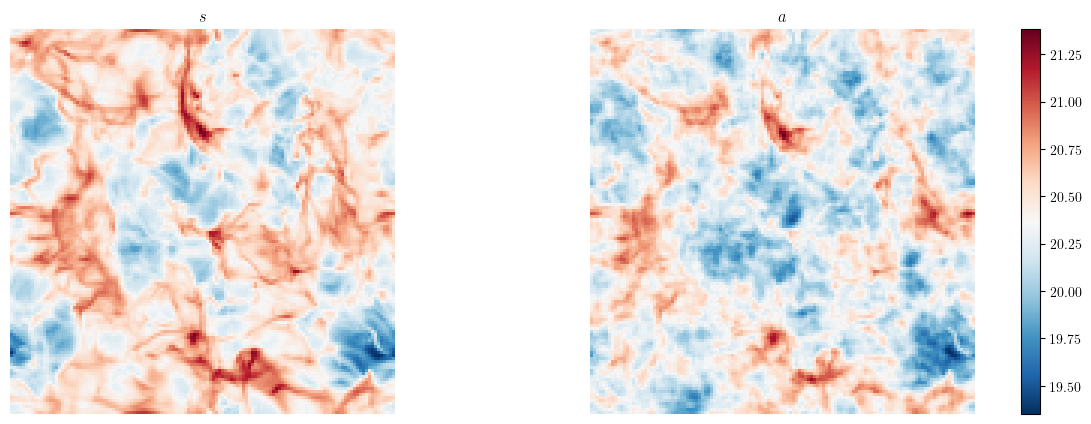

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, image, title in zip(
    axes,
    [s, a],
    [r"$s$", r"$a$"],
):
    im = ax.imshow(image, origin="lower", cmap="RdBu_r")
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)

### Define the three-channel fields

$$X_{\rm target,aux}^{(i)}=[d,n^{(i)},a],\qquad
X_{\rm run,aux}^{(i)}=[u+n^{(i)},d-u,a].$$

In [23]:
def target_aux(indices):
    nb = len(indices)
    return torch.stack([d_t.expand(nb, -1, -1), noise_t[indices], a_t.expand(nb, -1, -1)], dim=1)

def running_aux(candidate, indices):
    nb = len(indices)
    return torch.stack([candidate + noise_t[indices], (d_t-candidate).expand(nb, -1, -1), a_t.expand(nb, -1, -1)], dim=1)

## Define the cross-matrix

Here we define the cross matrix in the three-channel case
$$C_3=\begin{pmatrix}1&0&1\\0&1&0\\0&0&0\end{pmatrix}.$$

The off diagonal term includes cross statistics like

$$\phi(d, a)$$

**Important note:** Note that we are not making any a priori assumptions about the correlation between $s$ and $a$. We only use the data $d$ and $a$. 


In [24]:
aux_matrix = torch.tensor([[1,0,1],[0,1,0],[0,0,0]], dtype=torch.bool, device=device)

### Build the three-channel operator and store its normalization

In [25]:
aux_reference = torch.stack([d_t, noise_t[0], a_t])
aux_reference_dc = DataClass(aux_reference, pbc=True)
aux_op = aux_reference_dc.get_ST_op(WType="Bump-Steerable", compute_PS=False)
with torch.no_grad():
    aux_op.apply(aux_reference_dc, norm="store_ref", compute_cross_matrix=torch.eye(3, dtype=torch.bool, device=device))

def aux_features(batch):
    field = DataClass(batch, pbc=True)
    result = aux_op.apply(field, norm="load_ref", compute_cross_matrix=aux_matrix)
    return result.to_flatten(mean_along_batch=True, keepnans=False)

### Repeat the component separation with the auxiliary statistics

In [26]:
N_ITER = 1000

u_aux = d_t.clone().requires_grad_(True)
aux_optimizer = torch.optim.LBFGS([u_aux], lr=1.0, max_iter=1, line_search_fn=None)
aux_losses = []

for iteration in range(N_ITER):
    indices = rng.choice(len(noise_t), size=15, replace=False)
    with torch.no_grad():
        target = aux_features(target_aux(indices))

    def aux_closure():
        aux_optimizer.zero_grad()
        difference = aux_features(running_aux(u_aux, indices)) - target
        loss = difference.abs().square().sum()
        loss.backward()
        return loss

    loss = aux_optimizer.step(aux_closure)
    aux_losses.append(loss.item())

with torch.no_grad():
    u_aux.copy_(nyquist_cut(u_aux))

### Compare the reconstructions with and without auxiliary information

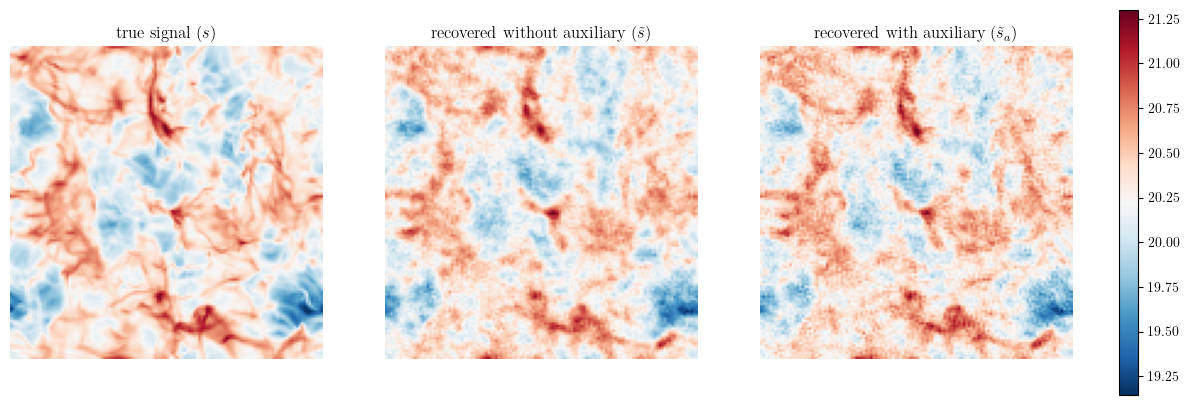

In [27]:
aux_recovered = u_aux.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, image, title in zip(
    axes,
    [s, recovered, aux_recovered],
    [r"true signal ($s$)", r"recovered without auxiliary ($\tilde s$)", r"recovered with auxiliary ($\tilde s_a$) "],
):
    im = ax.imshow(image, origin="lower", cmap="RdBu_r")
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)


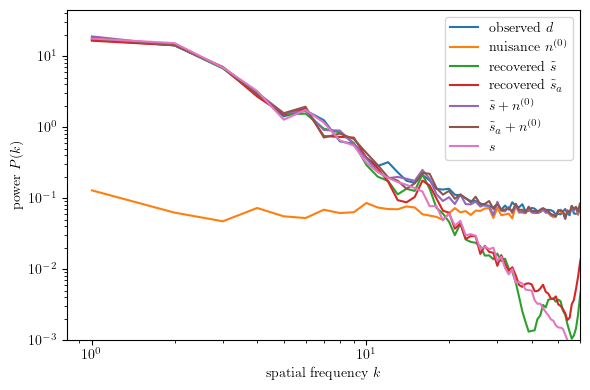

In [33]:
def isotropic_power_spectrum(image):
    # Average 2D Fourier power in integer radial bins.
    power_2d = np.abs(np.fft.fft2(image, norm="ortho")) ** 2
    height, width = image.shape
    ky = height * np.fft.fftfreq(height)
    kx = width * np.fft.fftfreq(width)
    ky, kx = np.meshgrid(ky, kx, indexing="ij")
    radial_bin = np.floor(np.sqrt(kx**2 + ky**2)).astype(int)

    max_bin = min(height, width) // 2
    valid = radial_bin <= max_bin
    power = np.bincount(
        radial_bin[valid].ravel(),
        weights=power_2d[valid].ravel(),
        minlength=max_bin + 1,
    )
    counts = np.bincount(
        radial_bin[valid].ravel(), minlength=max_bin + 1
    )
    return np.arange(1, max_bin + 1), (power / np.maximum(counts, 1))[1:]


noise_example = noise_samples[0]
posterior_predictive = recovered + noise_example
aux_posterior_predictive = aux_recovered + noise_example


k, observed_ps = isotropic_power_spectrum(d)
_, noise_ps = isotropic_power_spectrum(noise_example)
_, recovered_ps = isotropic_power_spectrum(recovered)
_, aux_recovered_ps = isotropic_power_spectrum(aux_recovered)
_, true_ps = isotropic_power_spectrum(s)
_, predictive_ps = isotropic_power_spectrum(posterior_predictive)
_, aux_predictive_ps = isotropic_power_spectrum(aux_posterior_predictive)


plt.figure(figsize=(6, 4))
plt.loglog(k, observed_ps, label=r"observed $d$")
plt.loglog(k, noise_ps, label=r"nuisance $n^{(0)}$")
plt.loglog(k, recovered_ps, label=r"recovered $\tilde{s}$")
plt.loglog(k, aux_recovered_ps, label=r"recovered $\tilde{s}_a$")
plt.loglog(k, predictive_ps, label=r"$\tilde{s}+n^{(0)}$")
plt.loglog(k, aux_predictive_ps, label=r"$\tilde{s}_a+n^{(0)}$")
plt.loglog(k, true_ps, label=r"$s$")
plt.xlabel(r"spatial frequency $k$")
plt.ylabel("power $P(k)$")
plt.xlim(xmax = 60)
plt.ylim(ymin = 1e-3)
plt.legend()
plt.tight_layout()


## Stage C — Application to real data

We now apply the same component-separation strategy to real observations.

The observed fields are two correlated polarization maps observed at $353$ GHz defined on a $~ 20^\circ \times 20^\circ $ square patch

$$
d_Q,\ d_U\in\mathbb R^{128\times128},
$$

and the unknown signals we want to recover are denoted by

$$
\tilde s_Q,\ \tilde s_U.
$$

For each polarization component, the observation is modeled as

$$
d_Q=s_Q+c_{Q,0},
\qquad
d_U=s_U+c_{U,0}.
$$

We do not know the particular contaminations $c_{Q,0}$ and $c_{U,0}$ present in the observations. We do, however, have an ensemble of paired nuisance realizations

$$
\left\{
\left(c_Q^{(i)},c_U^{(i)}\right)
\right\}_{i=1}^{N_{\rm nuisance}},
$$

which represents the expected instrumental noise and CMB residuals.

We also use an intensity map observed at 857 GHz

$$
d_I=I857-\langle I857\rangle
$$

as an auxiliary tracer. This map is not optimized. Its role is to provide morphological information that may be correlated with polarized dust. 

**Notice that the correlation between intensity and polarization is not assumed anywhere**

The optimization variables are the two candidate signal maps

$$
u=
\begin{bmatrix}
u_Q\\
u_U
\end{bmatrix}.
$$

As in the controlled example, we will encode the desired statistical constraints by constructing target and running tensors. The target describes the observed maps, nuisance ensemble, and auxiliary tracer. The running tensor describes the corresponding fields implied by the current estimates $u_Q$ and $u_U$.

The loss will retain exactly the same form:

$$
\mathcal L(u)
=
\frac{1}{M}
\sum_{m=1}^{M}
\left|
\overline{\Phi}_{R,m}
\left(X_{\rm run}(u)\right)
-
\overline{\Phi}_{R,m}
\left(X_{\rm target}\right)
\right|^2,
$$

where $\overline{\Phi}_R$ denotes the normalized STL statistics averaged over a minibatch of paired nuisance realizations.

After convergence, these maps provide the recovered components:

$$
(\tilde s_Q, \tilde s_U) = \argmin_{(u_Q, u_U)} \mathcal{L}[(u_Q, u_U)]
$$

Only the definitions of $X_{\rm target}$, $X_{\rm run}$, and the cross-matrix will change.

### Load observed Q/U, fixed I857, and paired Q/U nuisance maps

In [ ]:
planck = np.load("/path/to/data")
planck_dq, planck_du, planck_aux = planck["Q353"], planck["U353"], planck["I857"]
planck_noise_q, planck_noise_u = planck["noise_Q353"], planck["noise_U353"]
assert planck_dq.shape == planck_du.shape == planck_aux.shape == (128, 128)
assert planck_noise_q.shape == planck_noise_u.shape

### Define the five-channel objects

$$X_{\rm target}^{(i)}=[d_Q,n_Q^{(i)},d_U,n_U^{(i)},d_I],$$

$$X_{\rm run}^{(i)}=[u_Q+n_Q^{(i)},d_Q-u_Q,u_U+n_U^{(i)},d_U-u_U,d_I].$$

In [ ]:
pdq = torch.from_numpy(planck_dq).to(device, torch.float64)
pdu = torch.from_numpy(planck_du).to(device, torch.float64)
paux = torch.from_numpy(planck_aux - planck_aux.mean()).to(device, torch.float64)
pnq = torch.from_numpy(planck_noise_q).to(device, torch.float64)
pnu = torch.from_numpy(planck_noise_u).to(device, torch.float64)
bk._DEFAULT_DTYPE, bk._DEFAULT_COMPLEX_DTYPE = torch.float64, torch.complex128

In [ ]:
def planck_target(indices):
    nb = len(indices)
    return torch.stack([pdq.expand(nb,-1,-1),pnq[indices],pdu.expand(nb,-1,-1),pnu[indices],paux.expand(nb,-1,-1)], dim=1)

def planck_running(candidate, indices):
    nb = len(indices); uq, uu = candidate
    return torch.stack([uq+pnq[indices],(pdq-uq).expand(nb,-1,-1),uu+pnu[indices],(pdu-uu).expand(nb,-1,-1),paux.expand(nb,-1,-1)], dim=1)

### Select which auto and cross statistics to compute

$$

C_5 =

\begin{pmatrix}

1 & 0 & 1 & 0 & 1 \\

0 & 1 & 0 & 0 & 0 \\

1 & 0 & 1 & 0 & 1 \\

0 & 0 & 0 & 1 & 0 \\

1 & 0 & 1 & 0 & 0

\end{pmatrix}

$$

In [ ]:
planck_matrix = torch.tensor([[1,0,1,0,1],[0,1,0,0,0],[0,0,1,0,1],[0,0,0,1,0],[0,0,0,0,0]], dtype=torch.bool, device=device)

### Build the operator and store one fixed five-channel normalization

In [ ]:
pref = torch.stack([pdq,pnq[0],pdu,pnu[0],paux])[None]
pref_dc = DataClass(pref, pbc=False)
pop = pref_dc.get_ST_op(WType="Bump-Steerable", compute_PS=True, power_spectrum_method="gaussian_rings")
with torch.no_grad():
    pop.apply(pref_dc, norm="store_ref", compute_cross_matrix=torch.eye(5, dtype=torch.bool, device=device))

def planck_features(batch):
    result = pop.apply(DataClass(batch, pbc=False), norm="load_ref", compute_cross_matrix=planck_matrix)
    return result.to_flatten(mean_along_batch=True, keepnans=False)

### Optimize Q and U jointly; I857 remains fixed

In [ ]:
u_qu = torch.stack([pdq.clone(), pdu.clone()]).requires_grad_(True)
poptimizer = torch.optim.LBFGS([u_qu], lr=1.0, max_iter=1, line_search_fn=None)
planck_losses = []

for iteration in range(60):
    indices = rng.choice(len(pnq), size=15, replace=False)
    with torch.no_grad():
        target = planck_features(planck_target(indices))

    def planck_closure():
        poptimizer.zero_grad()
        difference = planck_features(planck_running(u_qu, indices)) - target
        loss = difference.abs().square().sum()
        loss.backward()
        return loss

    loss = poptimizer.step(planck_closure)
    planck_losses.append(loss.item())

with torch.no_grad():
    u_qu[0].copy_(nyquist_cut(u_qu[0]))
    u_qu[1].copy_(nyquist_cut(u_qu[1]))

### Display recovered Q/U maps and residuals

In [ ]:
qu = u_qu.detach().cpu().numpy()
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, image, title in zip(axes.ravel(), [planck_dq,qu[0],planck_dq-qu[0],planck_du,qu[1],planck_du-qu[1]], ["Q data","Q recovered","Q residual","U data","U recovered","U residual"]):
    ax.imshow(image, origin="lower", cmap="RdBu_r")
    ax.set_title(title); ax.axis("off")
plt.tight_layout()